##  Step 1: Import Libraries

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



##  Step 2: Load the Dataset

In [47]:
df = pd.read_csv('loan_data (1).csv')
# df.shape
df.isnull().sum()
df.dropna(inplace = True)

# Drop 'applicant_id' as it's an identifier and not a feature
df = df.drop('applicant_id', axis=1)

# Identify categorical columns (excluding the target variable 'loan_status')
# Assuming 'loan_status' is the only non-numeric column left that's not a feature after dropping 'applicant_id'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'loan_status' in categorical_cols:
    categorical_cols.remove('loan_status')

# Apply one-hot encoding to the identified categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("DataFrame after dropping 'applicant_id' and one-hot encoding categorical features:")
display(df.head())

DataFrame after dropping 'applicant_id' and one-hot encoding categorical features:


,age,annual_income,loan_amount,monthly_emi,credit_score,existing_loans,has_property,loan_status,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai,city_Pune,education_Not Graduate,employment_type_Freelancer,employment_type_Salaried,employment_type_Self-Employed
0,50,372619,246324,34598.0,572.0,0,0,Approved,0,0,0,1,0,0,0,0,1,0
1,36,512306,302698,31961.0,780.0,4,1,Rejected,0,1,0,0,0,0,0,0,1,0
2,29,309749,112456,14602.0,715.0,0,1,Approved,0,0,0,0,0,0,0,0,0,1
3,42,844535,1008733,11256.0,805.0,1,0,Approved,0,0,0,0,0,0,1,0,1,0
4,40,474162,394772,22584.0,723.0,3,0,Approved,0,1,0,0,0,0,1,0,0,0


##  Step 3: Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 998
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            950 non-null    int64  
 1   annual_income                  950 non-null    int64  
 2   loan_amount                    950 non-null    int64  
 3   monthly_emi                    950 non-null    float64
 4   credit_score                   950 non-null    float64
 5   existing_loans                 950 non-null    int64  
 6   has_property                   950 non-null    int64  
 7   loan_status                    950 non-null    object 
 8   city_Chennai                   950 non-null    int64  
 9   city_Delhi                     950 non-null    int64  
 10  city_Hyderabad                 950 non-null    int64  
 11  city_Kolkata                   950 non-null    int64  
 12  city_Mumbai                    950 non-null    int64  


<Axes: xlabel='loan_status', ylabel='count'>

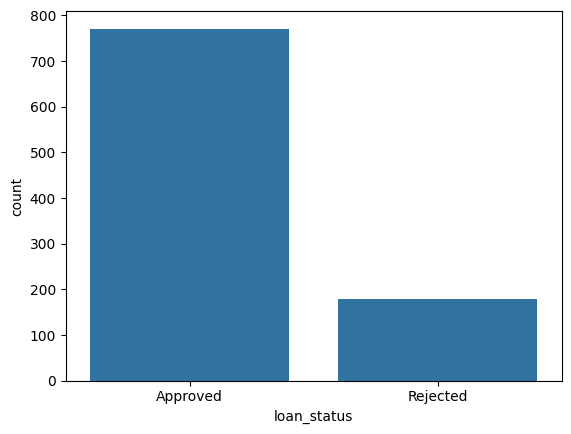

In [48]:
# Basic info
df.info()
# Statistical summary
df.describe()
# Missing values
df.isnull().sum()
# Target variable distribution
df['loan_status'].value_counts()

# Correlation heatmap (numeric columns only)
sns.countplot(data = df, x ='loan_status')

from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()
df_copy['loan_status'] = Le.fit_transform(df_copy['loan_status'])
df_copy['loan_status'].head()

In [49]:
# Define Features (X) and Target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
print("Target variable 'loan_status' encoded successfully:")
print(pd.Series(y).value_counts())

Target variable 'loan_status' encoded successfully:
0    771
1    179
Name: count, dtype: int64


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"Data split into training (X_train: {X_train.shape}, y_train: {y_train.shape}) and testing (X_test: {X_test.shape}, y_test: {y_test.shape}) sets.")

Data split into training (X_train: (636, 17), y_train: (636,)) and testing (X_test: (314, 17), y_test: (314,)) sets.


# KNN

In [52]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix

### Feature Scaling for KNN

> KNN is sensitive to the scale of the features. We need to standardize the features so that all features contribute equally to the distance calculation.

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Feature scaled successfully ')

Feature scaled successfully 


### Train the KNN Model

> We will train a K-Nearest Neighbors classifier on the scaled training data.

In [54]:
# Initialize KNN classifier with n_neighbors (e.g., 5)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the classifier on the scaled training data
knn_classifier.fit(X_train_scaled, y_train)
print("KNN trained successfully ")

KNN trained successfully 


### Make Predictions with KNN

In [55]:
y_pred=knn_classifier.predict(X_test_scaled)
y_pred[:5]

array([0, 0, 0, 0, 0])

In [56]:
compare= pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
compare.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,0,0
8,1,0
9,0,0


### Evaluate the KNN Model

> We will evaluate the KNN model using a classification report and confusion matrix to understand its performance.

In [57]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.96      0.86       247
           1       0.21      0.04      0.07        67

    accuracy                           0.76       314
   macro avg       0.50      0.50      0.47       314
weighted avg       0.66      0.76      0.69       314

[[236  11]
 [ 64   3]]


### Visualize Confusion Matrix for KNN

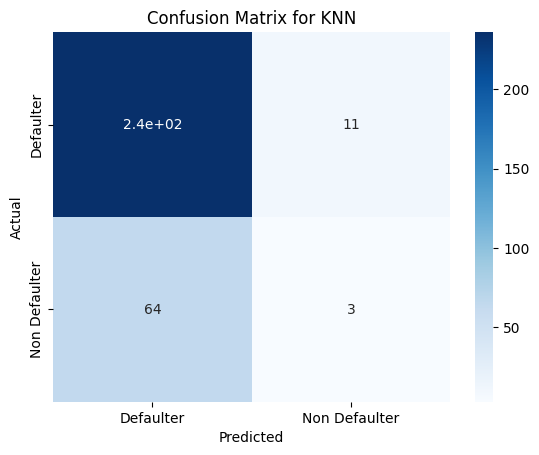

In [58]:
C_knn = confusion_matrix(y_test, y_pred)
sns.heatmap(C_knn, annot=True, cmap='Blues' ,
            xticklabels=['Defaulter' ,'Non Defaulter'], yticklabels =['Defaulter','Non Defaulter'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN')
plt.show()

### Elbow Method for Optimal K (K-Means Clustering)



### Explanation of the Elbow Method

The Elbow Method is a heuristic used in determining the number of clusters in a dataset for K-means clustering. The method works as follows:

1.  **Calculate WCSS (Within-Cluster Sum of Squares):** For each value of K (number of clusters), we calculate the sum of squared distances between each point and the centroid of its assigned cluster. A smaller WCSS value generally means better clustering.
2.  **Plot WCSS against K:** We plot the WCSS values for a range of K values.
3.  **Identify the 'Elbow' Point:** The 'elbow' point on the plot is where the rate of decrease in WCSS significantly changes. This point often suggests an optimal K, as adding more clusters beyond this point does not lead to a substantial improvement in WCSS, implying diminishing returns.

This method helps in finding a balance between having too few clusters (high WCSS, poor representation) and too many clusters (low WCSS, but potentially overfitting or creating trivial clusters).

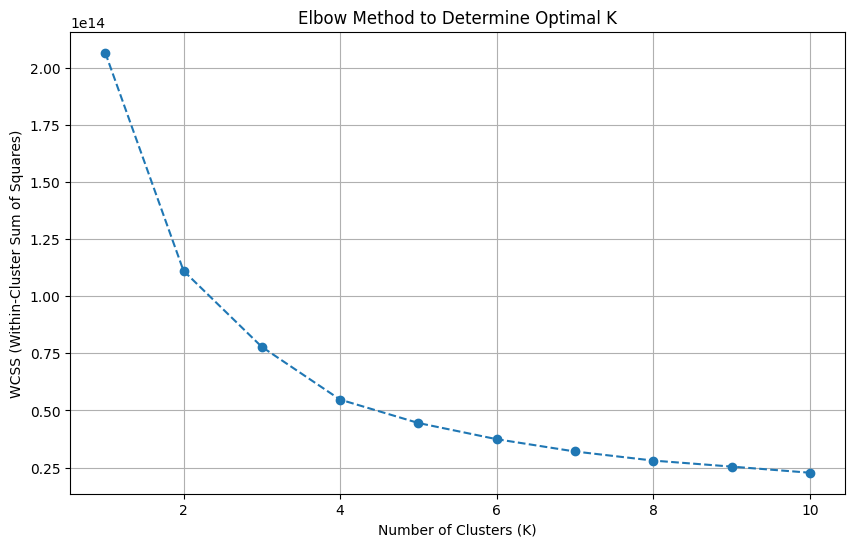

WCSS values for K from 1 to 10:
[206509405155967.84, 111083046452023.61, 77814547463892.77, 54745507763880.97, 44504373439485.26, 37426943080358.97, 32041915358649.125, 28068226399271.49, 25441308117365.195, 22756803572016.906]
Look for the 'elbow' point in the graph where the decrease in WCSS slows down significantly.


In [59]:
from sklearn.cluster import KMeans

# Initialize an empty list to store WCSS values
wcss = []

# Define a range of K values to test
# It's generally good practice to start K from 1 up to a reasonable number
# For example, up to 10 or 15, or based on the number of samples in your data.
max_k = 10

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init is recommended for robust results
    kmeans.fit(X) # Use your feature set X for clustering
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

print(f"WCSS values for K from 1 to {max_k}:\n{wcss}")
print("Look for the 'elbow' point in the graph where the decrease in WCSS slows down significantly.")

## Resources

*   [Scikit-learn Documentation](https://scikit-learn.org/stable/)
*   [Pandas Documentation](https://pandas.pydata.org/pandas-docs/stable/)
*   [Seaborn Documentation](https://seaborn.pydata.org/)
*   [Matplotlib Documentation](https://matplotlib.org/stable/)
*   [Imbalanced-learn Documentation](https://imbalanced-learn.org/stable/)

## Resources

Here are some useful resources related to the techniques and libraries used in this notebook:

*   **Scikit-learn Documentation:** [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)
*   **Gaussian Naïve Bayes:** [https://scikit-learn.org/stable/modules/naive_bayes.html#gaussian-naive-bayes](https://scikit-learn.org/stable/modules/naive_bayes.html#gaussian-naive-bayes)
*   **K-Nearest Neighbors (KNN):** [https://scikit-learn.org/stable/modules/neighbors.html#classification](https://scikit-learn.org/stable/modules/neighbors.html#classification)
*   **SMOTE (Synthetic Minority Over-sampling Technique):** [https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)
*   **Confusion Matrix:** [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
*   **Classification Report:** [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
*   **Seaborn Heatmap:** [https://seaborn.pydata.org/generated/seaborn.heatmap.html](https://seaborn.pydata.org/generated/seaborn.heatmap.html)